# Dataset overview

## Load metadata

In [4]:
import numpy as np
import pandas as pd

In [5]:
from google.colab import files
uploaded = files.upload()

Saving participants.tsv to participants (1).tsv
Saving phenotype.tsv to phenotype (1).tsv


In [6]:
participants = pd.read_csv("participants.tsv", sep="\t")
phenotype = pd.read_csv("phenotype.tsv", sep="\t")

In [7]:
participants.head()

,participant_id,age,sex,BMI,group,infusion_1,infusion_2
0,sub-MOA101,29.0,M,27.84,MDD,d,p
1,sub-MOA102,35.0,F,33.17,MDD,p,d
2,sub-MOA103,29.0,M,30.15,MDD,p,NaN
3,sub-MOA104,45.0,F,24.23,MDD,d,p
4,sub-MOA105,20.0,F,24.17,MDD,d,p


In [8]:
phenotype.head()

,participant_id,session_id,MADRS_Total,HAMD_Bech,HAM17_Total
0,sub-MOA101,ses-b0,35.0,14.0,20.0
1,sub-MOA101,ses-d2,24.0,8.0,13.0
2,sub-MOA101,ses-d10,NaN,NaN,NaN
3,sub-MOA101,ses-p2,33.0,13.0,20.0
4,sub-MOA101,ses-p10,39.0,15.0,23.0


In [9]:
participants.columns

Index(['participant_id', 'age', 'sex', 'BMI', 'group', 'infusion_1',
       'infusion_2'],
      dtype='object')

In [10]:
phenotype.columns

Index(['participant_id', 'session_id', 'MADRS_Total', 'HAMD_Bech',
       'HAM17_Total'],
      dtype='object')

In [11]:
participants.shape

(58, 7)

In [12]:
phenotype.shape

(236, 5)

In [13]:
participants["group"].value_counts()

,count
group,
MDD,33
HC,22
BP,3


In [14]:
participants["infusion_1"].value_counts()

,count
infusion_1,
d,28
p,24


In [15]:
participants["infusion_2"].value_counts()

,count
infusion_2,
p,23
d,22


In [16]:
phenotype["session_id"].value_counts()

,count
session_id,
ses-b0,57
ses-d2,48
ses-p2,45
ses-p10,43
ses-d10,42


In [17]:
phenotype[phenotype["participant_id"] == "sub-MOA111"]

,participant_id,session_id,MADRS_Total,HAMD_Bech,HAM17_Total
42,sub-MOA111,ses-b0,30.0,12.0,16.0
43,sub-MOA111,ses-d2,0.0,1.0,2.0
44,sub-MOA111,ses-d10,6.0,NaN,NaN


### Participant characteristics

In [18]:
participants["infusion_1"] = participants["infusion_1"].replace({
    "d": "ketamine",
    "p": "placebo"
})

participants["infusion_2"] = participants["infusion_2"].replace({
    "d": "ketamine",
    "p": "placebo"
})

In [19]:
participants.head()

,participant_id,age,sex,BMI,group,infusion_1,infusion_2
0,sub-MOA101,29.0,M,27.84,MDD,ketamine,placebo
1,sub-MOA102,35.0,F,33.17,MDD,placebo,ketamine
2,sub-MOA103,29.0,M,30.15,MDD,placebo,NaN
3,sub-MOA104,45.0,F,24.23,MDD,ketamine,placebo
4,sub-MOA105,20.0,F,24.17,MDD,ketamine,placebo


The dataset contains clinical and neuroimaging data from a ketamine infusion study.
It contains three participant groups:

- Major Depressive Disorder (MDD)
- Bipolar disorder (BP)
- Healthy controls (HC)

Most participants belong to the MDD group, which is expected given the focus of ketamine research on depression.

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

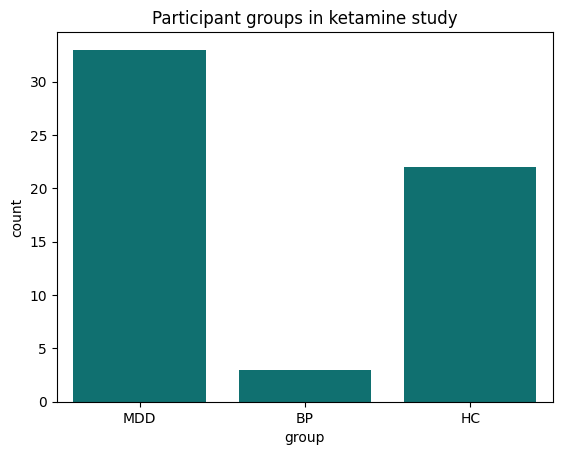

In [21]:
sns.countplot(data=participants, x="group", color='teal')

plt.title("Participant groups in ketamine study")
plt.show()

In [22]:
participants["age"].describe()

,age
count,56.000000
mean,35.232143
std,10.162303
min,20.000000
25%,29.000000
50%,32.000000
75%,41.500000
max,66.000000


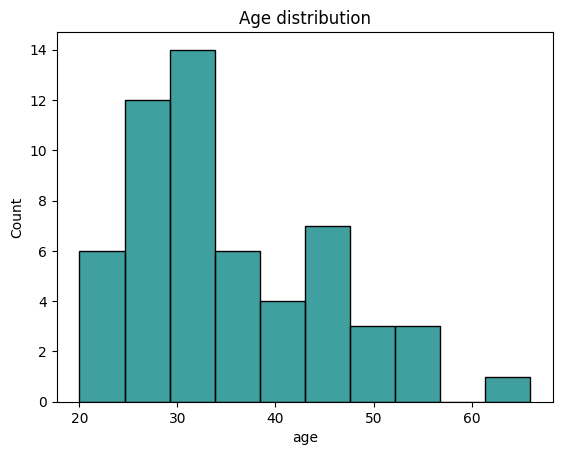

In [23]:
sns.histplot(participants["age"], bins=10, color='teal')
plt.title("Age distribution")
plt.show()

### Experimental design

Depression scores across sessions

The MADRS scale measures severity of depressive symptoms.

Baseline scores (ses-b0) represent depressive severity before treatment.

Sessions d2 and d10 correspond to follow-ups after ketamine infusion,
while p2 and p10 correspond to follow-ups after placebo.

Lower MADRS scores indicate improvement in depressive symptoms.

In [24]:
phenotype["session_id"].value_counts()

,count
session_id,
ses-b0,57
ses-d2,48
ses-p2,45
ses-p10,43
ses-d10,42


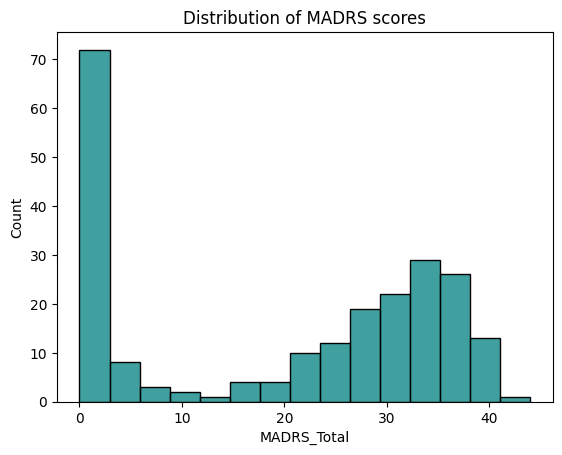

In [25]:
sns.histplot(phenotype["MADRS_Total"].dropna(), bins=15, color='teal')
plt.title("Distribution of MADRS scores")
plt.show()

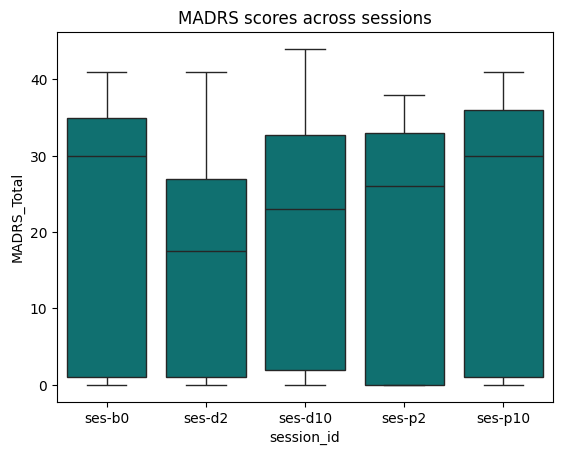

In [26]:
sns.boxplot(data=phenotype, x="session_id", y="MADRS_Total", color='teal')
plt.title("MADRS scores across sessions")
plt.show()



Clinical measurements (phenotype) were merged with participant metadata
to create a unified analysis dataset.

In [27]:
df = phenotype.merge(participants, on="participant_id")

df.head()

,participant_id,session_id,MADRS_Total,HAMD_Bech,HAM17_Total,age,sex,BMI,group,infusion_1,infusion_2
0,sub-MOA101,ses-b0,35.0,14.0,20.0,29.0,M,27.84,MDD,ketamine,placebo
1,sub-MOA101,ses-d2,24.0,8.0,13.0,29.0,M,27.84,MDD,ketamine,placebo
2,sub-MOA101,ses-d10,NaN,NaN,NaN,29.0,M,27.84,MDD,ketamine,placebo
3,sub-MOA101,ses-p2,33.0,13.0,20.0,29.0,M,27.84,MDD,ketamine,placebo
4,sub-MOA101,ses-p10,39.0,15.0,23.0,29.0,M,27.84,MDD,ketamine,placebo


In [28]:
df.columns

Index(['participant_id', 'session_id', 'MADRS_Total', 'HAMD_Bech',
       'HAM17_Total', 'age', 'sex', 'BMI', 'group', 'infusion_1',
       'infusion_2'],
      dtype='object')

In [29]:
df["condition"] = df["session_id"].map({
    "ses-b0": "baseline",
    "ses-d2": "ketamine_2d",
    "ses-d10": "ketamine_10d",
    "ses-p2": "placebo_2d",
    "ses-p10": "placebo_10d"
})

In [30]:
df.head()

,participant_id,session_id,MADRS_Total,HAMD_Bech,HAM17_Total,age,sex,BMI,group,infusion_1,infusion_2,condition
0,sub-MOA101,ses-b0,35.0,14.0,20.0,29.0,M,27.84,MDD,ketamine,placebo,baseline
1,sub-MOA101,ses-d2,24.0,8.0,13.0,29.0,M,27.84,MDD,ketamine,placebo,ketamine_2d
2,sub-MOA101,ses-d10,NaN,NaN,NaN,29.0,M,27.84,MDD,ketamine,placebo,ketamine_10d
3,sub-MOA101,ses-p2,33.0,13.0,20.0,29.0,M,27.84,MDD,ketamine,placebo,placebo_2d
4,sub-MOA101,ses-p10,39.0,15.0,23.0,29.0,M,27.84,MDD,ketamine,placebo,placebo_10d


### MADRS analysis

MADRS scores represent severity of depressive symptoms.

Lower scores indicate improvement.

Comparing sessions after ketamine infusion (d2, d10) with placebo follow-ups (p2, p10)
can provide preliminary evidence of treatment effects.

In [31]:
df["condition"].value_counts()

,count
condition,
baseline,57
ketamine_2d,48
placebo_2d,45
placebo_10d,43
ketamine_10d,42


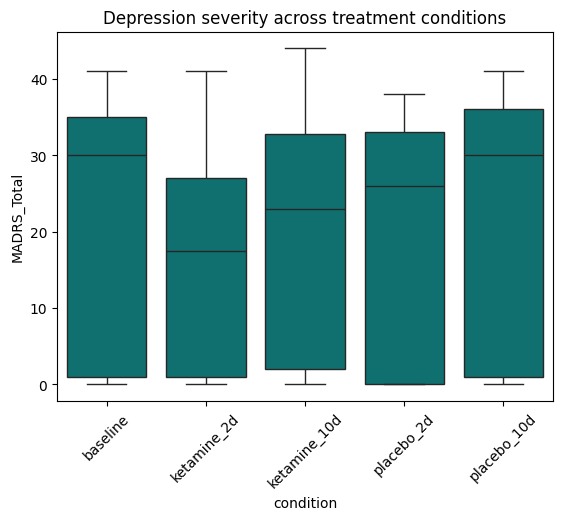

In [32]:
sns.boxplot(data=df, x="condition", y="MADRS_Total", color='teal')

plt.title("Depression severity across treatment conditions")
plt.xticks(rotation=45)
plt.show()

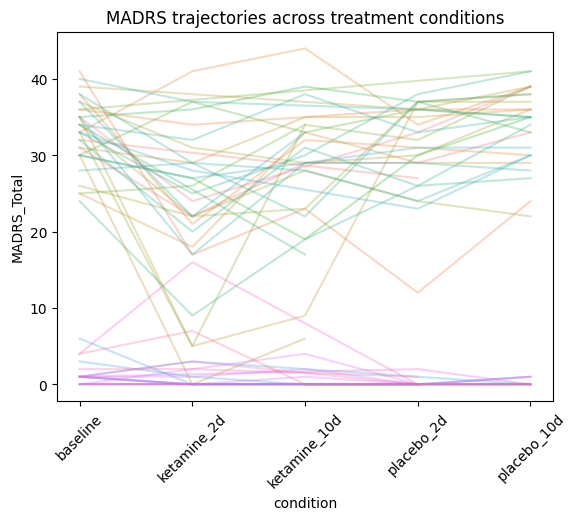

In [33]:
sns.lineplot(
    data=df,
    x="condition",
    y="MADRS_Total",
    hue="participant_id",
    legend=False,
    alpha=0.3
)

plt.title("MADRS trajectories across treatment conditions")
plt.xticks(rotation=45)
plt.show()

### Ketamine effect in MDD


In [34]:
mdd = df[df["group"] == "MDD"]

In [35]:
mdd.shape

(140, 12)

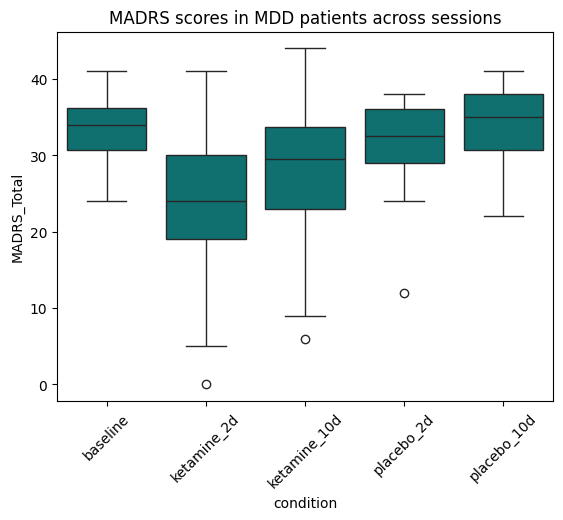

In [36]:
sns.boxplot(data=mdd, x="condition", y="MADRS_Total", color='teal')

plt.title("MADRS scores in MDD patients across sessions")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_219/1582056371.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:teal'` for the same effect.

  sns.boxplot(data=df, x="condition", y="MADRS_Total", hue="group", color='teal')


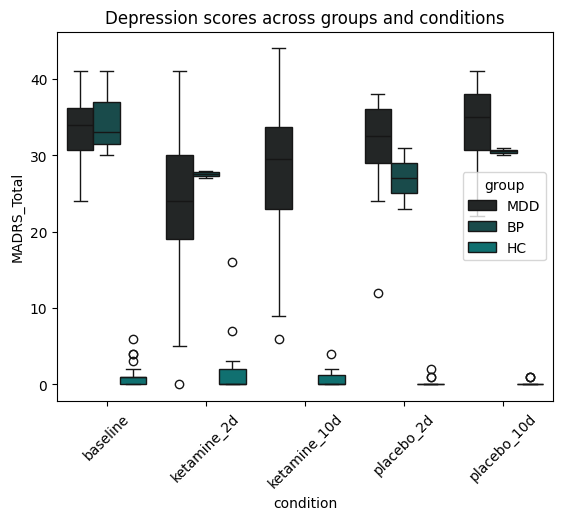

In [37]:
sns.boxplot(data=df, x="condition", y="MADRS_Total", hue="group", color='teal')

plt.title("Depression scores across groups and conditions")
plt.xticks(rotation=45)
plt.show()

In [38]:
mdd.groupby("condition")["MADRS_Total"].mean()

,MADRS_Total
condition,
baseline,33.375000
ketamine_10d,28.230769
ketamine_2d,23.592593
placebo_10d,34.192308
placebo_2d,31.307692


In [39]:
df.groupby(["group","condition"])["MADRS_Total"].mean()

group  condition   
BP     baseline        34.666667
       ketamine_2d     27.500000
       placebo_10d     30.500000
       placebo_2d      27.000000
HC     baseline         1.333333
       ketamine_10d     0.750000
       ketamine_2d      1.941176
       placebo_10d      0.230769
       placebo_2d       0.235294
MDD    baseline        33.375000
       ketamine_10d    28.230769
       ketamine_2d     23.592593
       placebo_10d     34.192308
       placebo_2d      31.307692
Name: MADRS_Total, dtype: float64

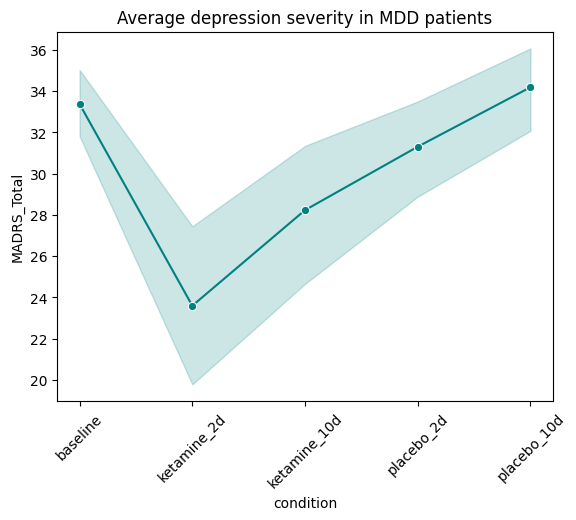

In [40]:
sns.lineplot(
    data=mdd,
    x="condition",
    y="MADRS_Total",
    estimator="mean",
    marker="o",
    color='teal'
)

plt.title("Average depression severity in MDD patients")
plt.xticks(rotation=45)
plt.show()

Major Depressive Disorder (MDD) participants show a decrease in MADRS scores
following ketamine sessions compared with placebo follow-ups.

This pattern is consistent with previous findings that ketamine produces
rapid antidepressant effects in treatment-resistant depression.

## Summary

In this exploratory analysis we examined the clinical structure of the dataset.

Key observations:

- The dataset includes participants with Major Depressive Disorder, Bipolar Disorder, and Healthy Controls.
- Depression severity was measured using MADRS and HAMD scales.
- The study uses a cross-over design where participants receive both ketamine and placebo.
- Preliminary inspection suggests a reduction in MADRS scores following ketamine sessions.

These findings provide a clinical context for the neuroimaging analysis that will follow in the next stage.